In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Inspect nwb file

In [2]:
from pynwb import NWBHDF5IO

import sys
sys.path.append('..')

In [3]:
import warnings

nwb_path = r"X:\Personnel\MaryBeth\OpenScope\001709\sub-815059\sub-815059_ses-multiplane-ophys-815059-2025-10-23-11-51-43_ophys.nwb"

with warnings.catch_warnings():
    warnings.filterwarnings("ignore", message="Ignoring cached namespace")
    io = NWBHDF5IO(nwb_path, "r", load_namespaces=True)
    nwb = io.read()

print(nwb)

root abc.NdxEventsNWBFile at 0x2440149596768
Fields:
  acquisition: {
    raw_running_wheel_rotation <class 'pynwb.base.TimeSeries'>,
    running_wheel_signal_voltage <class 'pynwb.base.TimeSeries'>,
    running_wheel_supply_voltage <class 'pynwb.base.TimeSeries'>
  }
  devices: {
    MESO.1 <class 'pynwb.device.Device'>
  }
  experimenter: ["['NSB-1007', 'Jerome Lecoq']"]
  file_create_date: [datetime.datetime(2026, 2, 3, 8, 51, 40, 904295, tzinfo=tzutc())]
  identifier: 40420797-235e-477f-83ff-3055d55ad972
  imaging_planes: {
    VISp_0 <class 'pynwb.ophys.ImagingPlane'>,
    VISp_1 <class 'pynwb.ophys.ImagingPlane'>,
    VISp_2 <class 'pynwb.ophys.ImagingPlane'>,
    VISp_3 <class 'pynwb.ophys.ImagingPlane'>,
    VISp_4 <class 'pynwb.ophys.ImagingPlane'>,
    VISp_5 <class 'pynwb.ophys.ImagingPlane'>,
    VISp_6 <class 'pynwb.ophys.ImagingPlane'>,
    VISp_7 <class 'pynwb.ophys.ImagingPlane'>
  }
  institution: Allen Institute for Neural Dynamics
  intervals: {
    drifting_gratings

In [4]:
dg_stim_table = nwb.intervals["drifting_gratings_field_block_presentations"].to_dataframe()
print(dg_stim_table)

      start_time   stop_time                      stim_name    stim_type  \
id                                                                         
0      636.72617   637.72700  drifting_gratings_field_block  GratingStim   
1      638.97804   639.97884  drifting_gratings_field_block  GratingStim   
2      641.22993   642.23077  drifting_gratings_field_block  GratingStim   
3      643.48187   644.48271  drifting_gratings_field_block  GratingStim   
4      645.73380   646.73458  drifting_gratings_field_block  GratingStim   
...          ...         ...                            ...          ...   
1495  4003.38908  4004.38992  drifting_gratings_field_block  GratingStim   
1496  4005.64098  4006.64181  drifting_gratings_field_block  GratingStim   
1497  4007.89289  4008.89372  drifting_gratings_field_block  GratingStim   
1498  4010.14479  4011.14563  drifting_gratings_field_block  GratingStim   
1499  4012.39669  4013.39753  drifting_gratings_field_block  GratingStim   

     stim_b

In [5]:
planes = [k for k in nwb.processing.keys() if k.startswith('VISp_')]
print(planes)

['VISp_0', 'VISp_1', 'VISp_2', 'VISp_3', 'VISp_4', 'VISp_5', 'VISp_6', 'VISp_7']


global_roi_ids shape: (153,)
image_masks shape: (153, 512, 512)


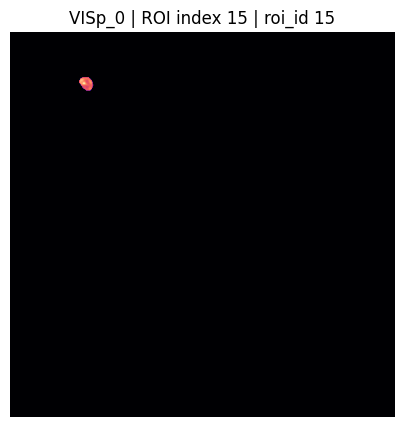

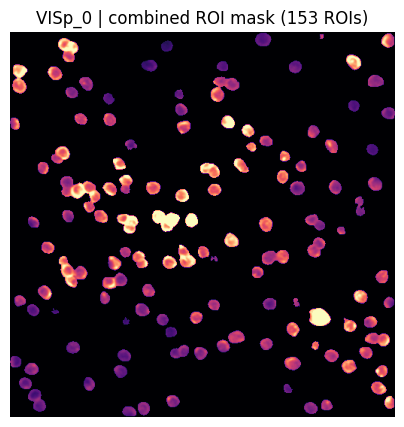

In [6]:
plane = 'VISp_0'
mod = nwb.processing[plane]

roi_table = mod['image_segmentation'].plane_segmentations['roi_table']
global_roi_ids = roi_table.id[:]
print(f"global_roi_ids shape: {global_roi_ids.shape}")

image_masks = roi_table['image_mask'][:]
print(f"image_masks shape: {image_masks.shape}")

# Show a single ROI mask
roi_idx = 15 
plt.figure(figsize=(5, 5))
plt.imshow(image_masks[roi_idx], cmap='magma')
plt.title(f"{plane} | ROI index {roi_idx} | roi_id {global_roi_ids[roi_idx]}")
plt.axis('off')
plt.show()

# Show union of all ROI masks
combined_mask = np.max(image_masks, axis=0)
plt.figure(figsize=(5, 5))
plt.imshow(combined_mask, cmap='magma')
plt.title(f"{plane} | combined ROI mask ({len(global_roi_ids)} ROIs)")
plt.axis('off')
plt.show()

## Write function to get ophys traces

In [7]:
PLANE_NAMES = planes

def get_ophys_traces(nwb, plane_names = None):
    if plane_names is None:
        plane_names = PLANE_NAMES
    
    all_traces = []
    all_roi_info = []
    timestamps = None
    
    for plane_name in plane_names:
        # print(f"Processing plane: {plane_name}")
        
        mod = nwb.processing[plane_name]
        
        series = mod['dff_timeseries'].roi_response_series['dff_timeseries']
        traces_plane = series.data[:] 

        roi_table = mod['image_segmentation'].plane_segmentations['roi_table']
        global_roi_ids = roi_table.id[:]

        # print(f"  traces shape: {traces_plane.shape}, n_rois: {len(global_roi_ids)}")

        if timestamps is None:
            timestamps = series.timestamps[:]

        all_traces.append(traces_plane)
        for local_idx, roi_id in enumerate(global_roi_ids):
            all_roi_info.append({
                'roi_id': f"{plane_name}_roi{roi_id}",
                'plane': plane_name,
                'local_roi_index': local_idx,
                'raw_roi_id': roi_id
            })

    combined_traces = np.concatenate(all_traces, axis=1)
    roi_info = pd.DataFrame(all_roi_info)
    
    print()

    return combined_traces, timestamps, roi_info

## Get traces for all planes

In [8]:
planes = [k for k in nwb.processing.keys() if k.startswith('VISp_')]
print(planes)

['VISp_0', 'VISp_1', 'VISp_2', 'VISp_3', 'VISp_4', 'VISp_5', 'VISp_6', 'VISp_7']


In [9]:
print(f"  Extracting dF/F traces...")
traces, timestamps, roi_info = get_ophys_traces(nwb, plane_names=planes)

print(f"  traces shape: {traces.shape}, n_rois: {len(roi_info)}")

roi_info = roi_info.copy()

  Extracting dF/F traces...

  traces shape: (38455, 812), n_rois: 812


## Look at what stimulus we have

In [10]:
stimulus_block = 'drifting_gratings_field_block_presentations'
stim_table = nwb.intervals[stimulus_block].to_dataframe()

condition_params = ['orientation', 'temporal_frequency', 'spatial_frequency', 'contrast']

stim_clean = stim_table[condition_params + ['start_time', 'stop_time']].dropna(
    subset=condition_params
).copy()

for param in condition_params:
    stim_clean[param] = pd.to_numeric(stim_clean[param], errors='coerce')

stim_clean['stimulus_condition_id'] = stim_clean.groupby(condition_params).ngroup()

print("Number of spatial conditions:", stim_clean['spatial_frequency'].nunique())
print("Number of temporal conditions:", stim_clean['temporal_frequency'].nunique())
print("Number of orientation conditions:", stim_clean['orientation'].nunique())
print("Number of unique stimulus conditions:", stim_clean['stimulus_condition_id'].nunique())
print()

print(stim_clean.head())


Number of spatial conditions: 5
Number of temporal conditions: 5
Number of orientation conditions: 4
Number of unique stimulus conditions: 100

    orientation  temporal_frequency  spatial_frequency  contrast  start_time  \
id                                                                             
0         135.0                15.0               0.32       0.8   636.72617   
1          90.0                 8.0               0.16       0.8   638.97804   
2           0.0                 8.0               0.08       0.8   641.22993   
3          90.0                 1.0               0.32       0.8   643.48187   
4          45.0                 2.0               0.02       0.8   645.73380   

    stop_time  stimulus_condition_id  
id                                    
0   637.72700                     99  
1   639.97884                     68  
2   642.23077                     17  
3   644.48271                     54  
4   646.73458                     30  


## Write functions to get response matrix

In [11]:
def conditionwise_dff_statistics(nwb, traces, timestamps, roi_info,
                                  stimulus_block='drifting_gratings_field_block_presentations'):
    
    stim_table = nwb.intervals[stimulus_block].to_dataframe()
    condition_params = ['orientation', 'temporal_frequency', 'spatial_frequency', 'contrast']
    stim_clean = stim_table[condition_params + ['start_time', 'stop_time']].dropna(
        subset=condition_params
    ).copy()

    for param in condition_params:
        stim_clean[param] = pd.to_numeric(stim_clean[param], errors='coerce')

    stim_clean['stimulus_condition_id'] = stim_clean.groupby(condition_params).ngroup()

    condition_ids = np.sort(stim_clean['stimulus_condition_id'].unique())

    roi_ids = roi_info['roi_id'].values
    n_rois = len(roi_ids)

    records = []
    for cond_id in condition_ids:
        cond_rows = stim_clean[stim_clean['stimulus_condition_id'] == cond_id]
        pres_means = []
        for _, row in cond_rows.iterrows():
            start, stop = row['start_time'], row['stop_time']
            mask = (timestamps >= start) & (timestamps < stop)
            if mask.sum() == 0:
                continue
            pres_means.append(traces[mask].mean(axis=0))

        cond_mean = np.stack(pres_means).mean(axis=0) if pres_means else np.zeros(n_rois)
        
        for roi_idx, roi_id in enumerate(roi_ids):
            records.append({
                'unit_id': roi_id,
                'stimulus_condition_id': cond_id,
                'spike_mean': float(cond_mean[roi_idx])
            })

    result_df = pd.DataFrame(records).set_index(['unit_id', 'stimulus_condition_id'])
        
    stimulus_conditions = stim_clean[condition_params + ['stimulus_condition_id']].drop_duplicates(
        subset='stimulus_condition_id'
    ).set_index('stimulus_condition_id').sort_index()    

    return result_df, stimulus_conditions


def build_response_matrix(conditionwise_stats_all, stimulus_conditions_all, unit_metadata_all,
                           units_data_all=None):
    
    unit_ids      = pd.Index([])
    condition_ids = pd.Index([])

    for conditionwise_stats, stimulus_conditions in zip(conditionwise_stats_all, stimulus_conditions_all):
        unit_ids      = unit_ids.union(conditionwise_stats.index.get_level_values('unit_id').unique())
        condition_ids = condition_ids.union(stimulus_conditions.index)

    n_rois       = len(unit_ids)
    n_conditions = len(condition_ids)
    print(f"Building matrix: {n_rois} ROIs x {n_conditions} conditions")

    response_matrix = np.zeros((n_rois, n_conditions))

    merged_meta = {}
    for meta_dict in unit_metadata_all:
        merged_meta.update(meta_dict)

    for i, unit in enumerate(unit_ids):
        unit_data = None
        for conditionwise_stats in conditionwise_stats_all:
            try:
                unit_data = conditionwise_stats.loc[unit]['spike_mean']
                break
            except KeyError:
                continue
        if unit_data is None:
            continue

        for j, cond_idx in enumerate(condition_ids):
            try:
                response_matrix[i, j] = float(unit_data.loc[cond_idx])
            except (KeyError, TypeError):
                response_matrix[i, j] = 0.0

    return response_matrix, unit_ids, condition_ids, merged_meta


## Build response matrix for all mice

In [12]:
from pathlib import Path

In [13]:
data_dir = Path(r"X:\Personnel\MaryBeth\OpenScope\001709")
output_dir = Path(r"C:\Users\MaryBeth\projects\SarvestaniLab\OpenScopeMouseV1\jupyternotebooks\ophys\results")

mouse_dirs = [d for d in data_dir.iterdir() if d.is_dir() and d.name.startswith('sub-')]
print(f"Found {len(mouse_dirs)} mouse directories")

Found 8 mouse directories


In [14]:
conditionwise_stats_all  = []
stimulus_conditions_all  = []
unit_metadata_all        = []
units_data_all           = []

for mouse_idx, mouse_dir in enumerate(mouse_dirs, 1):
    mouse_name = mouse_dir.name
    print("=" * 80)
    print(f"Processing Mouse {mouse_idx}/{len(mouse_dirs)}: {mouse_name}")
    print("=" * 80)

    io = None
    try:
        nwb_files = list(mouse_dir.glob("*.nwb"))
        if not nwb_files:
            print(f"  No NWB files found in {mouse_dir}, skipping.")
            continue
        nwb_path = nwb_files[0]

        io = NWBHDF5IO(str(nwb_path), "r", load_namespaces=True)
        nwb = io.read()

        # Detect available imaging planes
        available_planes = [k for k in nwb.processing.keys() if k.startswith('VISp_')]
        print(f"  Found planes: {available_planes}")

        # Extract dF/F traces across all planes
        print(f"  Extracting dF/F traces...")
        traces, timestamps, roi_info = get_ophys_traces(nwb, plane_names=available_planes)
        print(f"  traces shape: {traces.shape}, n_rois: {len(roi_info)}")

        # Namespace ROI IDs to avoid collisions across mice
        roi_info = roi_info.copy()
        roi_info['roi_id'] = roi_info['roi_id'].apply(lambda r: f"{mouse_name}__{r}")

        # Build unit metadata: roi_id -> (mouse_name, plane)
        unit_meta = {
            row['roi_id']: (mouse_name, row['plane'])
            for _, row in roi_info.iterrows()
        }
        unit_metadata_all.append(unit_meta)

        # Compute condition-wise mean dF/F
        print(f"  Computing conditionwise dF/F statistics...")
        conditionwise_stats, stimulus_conditions = conditionwise_dff_statistics(
            nwb, traces, timestamps, roi_info,
            stimulus_block='drifting_gratings_field_block_presentations'
        )
        print(f"  Done: {conditionwise_stats.shape[0]} (roi, condition) entries")

        conditionwise_stats_all.append(conditionwise_stats)
        stimulus_conditions_all.append(stimulus_conditions)

    except Exception as e:
        import traceback
        print(f"  ERROR on {mouse_name}: {e}")
        traceback.print_exc()

    finally:
        if io is not None:
            io.close()
            print(f"  NWB file closed for {mouse_name}")

# Save conditionwise stats
pd.concat(conditionwise_stats_all).to_csv(output_dir / "ophys_conditionwise_stats.csv")

# Save stimulus conditions
stimulus_conditions_all[0].to_csv(output_dir / "ophys_stimulus_conditions.csv")

# Save unit metadata
unit_metadata_df = pd.DataFrame(
    [(uid, mouse, plane) for d in unit_metadata_all for uid, (mouse, plane) in d.items()],
    columns=['roi_id', 'mouse_name', 'plane']
)
unit_metadata_df.to_csv(data_dir / "ophys_unit_metadata.csv", index=False)

print("Saved all outputs.")

Processing Mouse 1/8: sub-809092


c:\Users\MaryBeth\anaconda3\envs\openscope\lib\site-packages\hdmf\spec\namespace.py:535: UserWarning: Ignoring cached namespace 'core' version 2.8.0 because version 2.7.0 is already loaded.
  warn("Ignoring cached namespace '%s' version %s because version %s is already loaded."


  Found planes: ['VISp_0', 'VISp_1', 'VISp_2', 'VISp_3', 'VISp_4', 'VISp_5', 'VISp_6', 'VISp_7']
  Extracting dF/F traces...

  traces shape: (43579, 1099), n_rois: 1099
  Computing conditionwise dF/F statistics...
  Done: 109900 (roi, condition) entries
  NWB file closed for sub-809092
Processing Mouse 2/8: sub-810268


c:\Users\MaryBeth\anaconda3\envs\openscope\lib\site-packages\hdmf\spec\namespace.py:535: UserWarning: Ignoring cached namespace 'core' version 2.8.0 because version 2.7.0 is already loaded.
  warn("Ignoring cached namespace '%s' version %s because version %s is already loaded."


  Found planes: ['VISp_0', 'VISp_1', 'VISp_2', 'VISp_3', 'VISp_4', 'VISp_5', 'VISp_6', 'VISp_7']
  Extracting dF/F traces...

  traces shape: (43579, 858), n_rois: 858
  Computing conditionwise dF/F statistics...
  Done: 85800 (roi, condition) entries
  NWB file closed for sub-810268
Processing Mouse 3/8: sub-815059


...

  Found planes: ['VISp_0', 'VISp_1', 'VISp_2', 'VISp_3', 'VISp_4', 'VISp_5', 'VISp_6', 'VISp_7']
  Extracting dF/F traces...

  traces shape: (38465, 1041), n_rois: 1041
  Computing conditionwise dF/F statistics...
  Done: 104100 (roi, condition) entries
  NWB file closed for sub-823093
Processing Mouse 7/8: sub-826616


c:\Users\MaryBeth\anaconda3\envs\openscope\lib\site-packages\hdmf\spec\namespace.py:535: UserWarning: Ignoring cached namespace 'core' version 2.8.0 because version 2.7.0 is already loaded.
  warn("Ignoring cached namespace '%s' version %s because version %s is already loaded."


  Found planes: ['VISp_0', 'VISp_1', 'VISp_2', 'VISp_3', 'VISp_4', 'VISp_5', 'VISp_6', 'VISp_7']
  Extracting dF/F traces...

  traces shape: (43581, 866), n_rois: 866
  Computing conditionwise dF/F statistics...
  Done: 86600 (roi, condition) entries
  NWB file closed for sub-826616
Processing Mouse 8/8: sub-826619


c:\Users\MaryBeth\anaconda3\envs\openscope\lib\site-packages\hdmf\spec\namespace.py:535: UserWarning: Ignoring cached namespace 'core' version 2.8.0 because version 2.7.0 is already loaded.
  warn("Ignoring cached namespace '%s' version %s because version %s is already loaded."


  Found planes: ['VISp_0', 'VISp_1', 'VISp_2', 'VISp_3', 'VISp_4', 'VISp_5', 'VISp_6', 'VISp_7']
  Extracting dF/F traces...

  traces shape: (43582, 725), n_rois: 725
  Computing conditionwise dF/F statistics...
  Done: 72500 (roi, condition) entries
  NWB file closed for sub-826619
Saved all outputs.


In [15]:
response_matrix, unit_ids, condition_ids, merged_meta = build_response_matrix(
    conditionwise_stats_all, stimulus_conditions_all, unit_metadata_all
)

Building matrix: 6184 ROIs x 100 conditions


In [16]:
print(response_matrix.shape)
print(unit_ids.shape)
print(condition_ids.shape)
print(len(merged_meta))

(6184, 100)
(6184,)
(100,)
6184


In [ ]:
# Save response matrix
matrix_path = output_dir / f"ophys_response_matrix.npy"
np.save(matrix_path, response_matrix)
print(f"Saved: {matrix_path}  shape={response_matrix.shape}")

# Save unit and condition IDs
unit_ids_path = output_dir / f"ophys_unit_ids.csv"
pd.Series(unit_ids).to_csv(unit_ids_path, index=False)
print(f"Saved unit IDs: {unit_ids_path}")

condition_ids_path = output_dir / f"ophys_condition_ids.csv"
pd.Series(condition_ids).to_csv(condition_ids_path, index=False)
print(f"Saved condition IDs: {condition_ids_path}")

# Save merged metadata
metadata_path = output_dir / f"ophys_unit_metadata.csv"
metadata_df = pd.DataFrame.from_dict(merged_meta, orient='index')
metadata_df.to_csv(metadata_path)
print(f"Saved unit metadata: {metadata_path}")


Saved: C:\Users\MaryBeth\projects\SarvestaniLab\OpenScopeMouseV1\jupyternotebooks\ophys\results\response_matrix.npy  shape=(6184, 100)
Saved unit IDs: C:\Users\MaryBeth\projects\SarvestaniLab\OpenScopeMouseV1\jupyternotebooks\ophys\results\unit_ids.csv
Saved condition IDs: C:\Users\MaryBeth\projects\SarvestaniLab\OpenScopeMouseV1\jupyternotebooks\ophys\results\condition_ids.csv
Saved unit metadata: C:\Users\MaryBeth\projects\SarvestaniLab\OpenScopeMouseV1\jupyternotebooks\ophys\results\unit_metadata.csv
